In [18]:
#import libraries
import numpy as np  
import matplotlib.pyplot as plt
import scipy.stats as st
from numba import njit


In [19]:
#upload csv of SDSS
ra, dec, z, phot_u, phot_g, phot_r, phot_i, phot_z  = np.loadtxt('sdss_cutout.csv', unpack=True,skiprows=1, delimiter=',')
print (z)


[0.09762917 0.06773683 0.06335044 ... 0.10209855 0.06914159 0.07091606]


Text(0.5, 1.0, 'Empirical Cumulative Distribution Function')

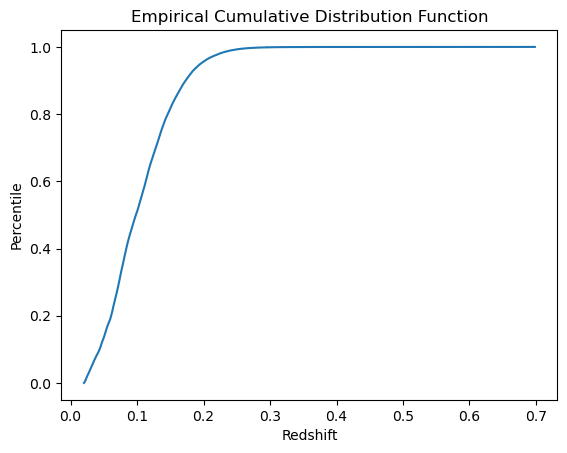

In [20]:
#Task 1
#sort the redshifts in ascending order
z_sort = np.sort(z)
#create figure
fig = plt.figure() 
#plot sorted redshifts against cumulative fraction
plt.step(z_sort,np.arange(1,len(z_sort)+1)/len(z_sort),label='empiricalCDF')
plt.xlabel('Redshift')
plt.ylabel('Percentile')
plt.title('Empirical Cumulative Distribution Function')


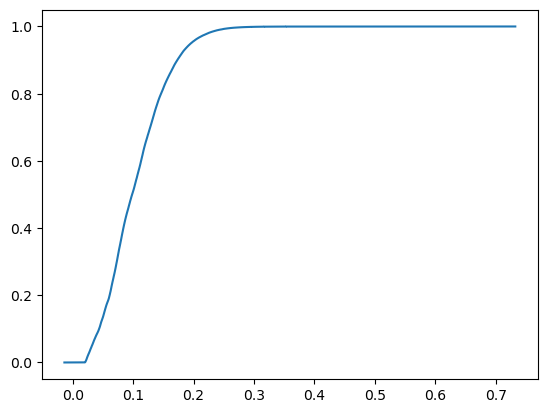

In [21]:
#plot scipy.stats.ecdf for sanity check
res= st.ecdf(z_sort)
ax = plt.subplot()
res.cdf.plot(ax)
plt.show()

Text(0.5, 1.0, 'R-band Magnitudes vs Redshift for Whole Distribution')

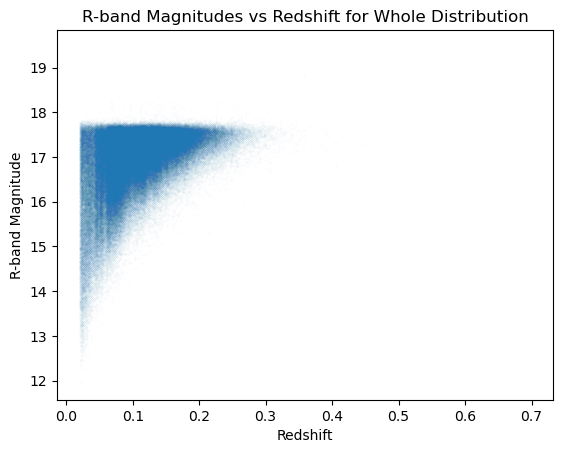

In [22]:
#plot the rband magnitudes against total redshift distribution
plt.scatter(z, phot_r, s=0.01, alpha=0.1)
plt.xlabel('Redshift')
plt.ylabel('R-band Magnitude')
plt.title('R-band Magnitudes vs Redshift for Whole Distribution')
#plt.ayhline(0.08, color='green')

In [23]:
#create a slice of the redshifts between 0.08 and 0.12
cut = (z > 0.08) & (z < 0.12)
ra, dec, z, phot_u, phot_r = ra[cut], dec[cut], z[cut], phot_u[cut], phot_r[cut]

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_108/2374884054.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.title('R-band Magnitudes vs Redshift for $0.08 < z \leq 0.12$')


Text(0.5, 1.0, 'R-band Magnitudes vs Redshift for $0.08 < z \\leq 0.12$')

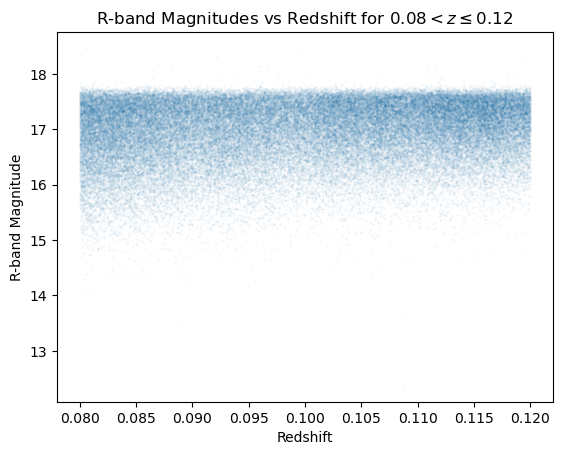

In [24]:
#create a scatter plot with the new redshift slice against r-band magnitude
plt.scatter(z, phot_r, s=0.1, alpha=0.1)
plt.xlabel('Redshift')
plt.ylabel('R-band Magnitude')
plt.title('R-band Magnitudes vs Redshift for $0.08 < z \leq 0.12$')

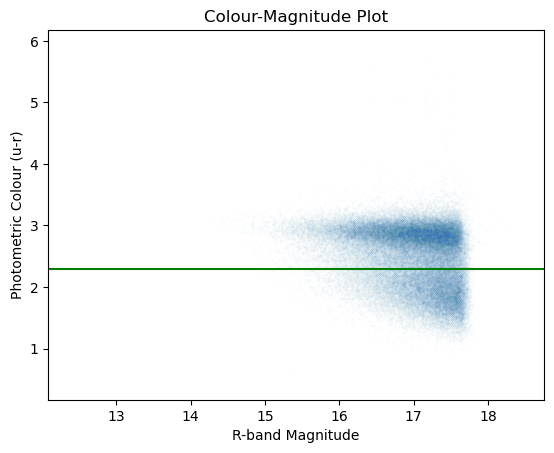

In [25]:
#task 2
#calculate photometric colour
phot_color = phot_u - phot_r
#plot photometric colour against r-band magnitude
plt.scatter(phot_r, phot_color, s=0.01, alpha=0.1)
plt.xlabel('R-band Magnitude')
plt.ylabel('Photometric Colour (u-r)')
plt.title ('Colour-Magnitude Plot')
#plot dividing line between blue and red galaxies
plt.axhline(2.3, color='green')

In [26]:
#construct new sets with blue and red galaxies
red = phot_color>2.3
blue = phot_color<=2.3
r_red  = phot_r[red]
r_blue = phot_r[blue]

n_red, n_blue = len(r_red), len(r_blue)
print(n_red)
print(n_blue)

60656
30456


In [27]:
#task 3
#compute mean and standard deviation of the new galaxy populations
mean_red,  std_red  = np.mean(r_red),  np.std(r_red)
mean_blue, std_blue = np.mean(r_blue), np.std(r_blue)

#use scipy.stats.bootstrap to compute 95% confidence intervals with the percentile method
res_red  = st.bootstrap((r_red,),  np.mean, confidence_level=0.95, n_resamples=1000, method='percentile')
res_blue = st.bootstrap((r_blue,), np.mean, confidence_level=0.95, n_resamples=1000, method='percentile')


print(mean_red, std_red)
print(mean_blue, std_blue)

16.884902132896997 0.5532295368731545
17.148581973026662 0.4317605611301002


In [28]:
print (res_red.standard_error, res_red.confidence_interval)
print(res_blue.standard_error,res_blue.confidence_interval)


0.0022017863920290115 ConfidenceInterval(low=np.float64(16.880567524442345), high=np.float64(16.889021959515958))
0.002520766768491899 ConfidenceInterval(low=np.float64(17.143390236786267), high=np.float64(17.153112311364342))


In [29]:
#calculate the confidence interval analytically using formula from lecture
#for red galaxies
red_low = mean_red-1.96*std_red/np.sqrt(n_red)
red_high = mean_red+1.96*std_red/np.sqrt(n_red)
#for blue galaxies
blue_low = mean_blue-1.96*std_blue/np.sqrt(n_blue)
blue_high = mean_blue+1.96*std_blue/np.sqrt(n_blue)

print(red_low, red_high)
print(blue_low, blue_high)

16.8804993776146 16.889304888179392
17.143732856629715 17.15343108942361


Text(0.5, 1.0, 'RA vs. DEC')

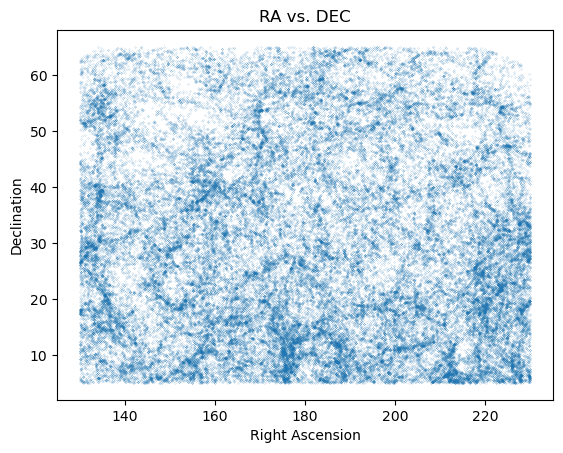

In [30]:
#task 4
#create a scatter plot of the right ascension against declination
plt.scatter(ra, dec, s=0.01)
plt.xlabel ('Right Ascension')
plt.ylabel ('Declination')
plt.title ('RA vs. DEC')

Text(0.5, 1.0, 'RA vs. Redshift')

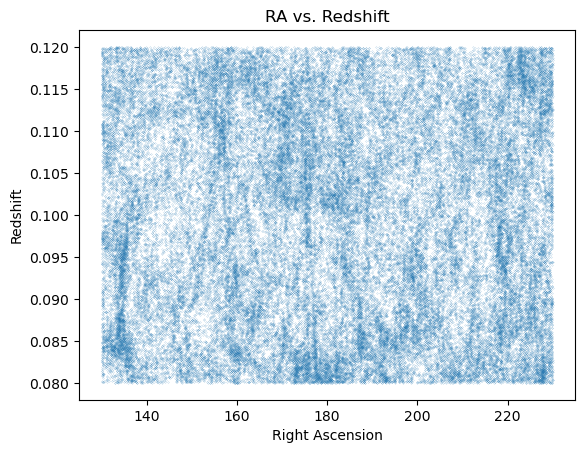

In [31]:
#create a scatter plot of the right ascension against redshift
plt.scatter(ra, z, s=0.01)
plt.xlabel ('Right Ascension')
plt.ylabel ('Redshift')
plt.title ('RA vs. Redshift')